# Predicción del Total de Compra en un E-commerce de Repostería con Árbol de Decisión (Regresión)

**Asignatura:** Inteligencia Artificial
**Programa:** Ingeniería de Sistemas — Semestre 8
**Universidad del Pacífico**
**Actividad:** Investigación, implementación y evaluación de un modelo de Machine Learning
**Modelo seleccionado:** Árbol de Decisión de Regresión (Decision Tree Regressor — `scikit-learn`)

---

## 1. Descripción del problema

Un e-commerce especializado en repostería registra sus transacciones (precio unitario, cantidad,
descuento, tiempo de navegación, distancia y costo de envío, categoría del producto, etc.), pero
el equipo de negocio necesita **estimar el valor total de una compra (`Total_Compra`)** de forma
anticipada, por ejemplo para dimensionar inventario, proyectar ingresos o detectar transacciones
atípicas antes de que se confirme el pago. El objetivo de este trabajo es construir un modelo de
**regresión** que, a partir de las características de una transacción, **prediga el valor numérico
del total de la compra**.

Se seleccionó el **Árbol de Decisión de Regresión** porque es un modelo interpretable, fácil de
visualizar, capaz de capturar relaciones no lineales entre variables numéricas y categóricas, y
muy usado como punto de partida en problemas de regresión antes de probar modelos de ensamble más
complejos (Random Forest, Gradient Boosting).

## 2. Objetivo del trabajo

**Objetivo general:** Implementar y evaluar un modelo de Árbol de Decisión de Regresión en Python
(scikit-learn) capaz de predecir el valor total de una transacción de e-commerce, siguiendo el
flujo completo de un proyecto de Machine Learning: preparación de datos, entrenamiento, validación,
evaluación y análisis crítico de resultados.

**Objetivos específicos:**

1. Investigar los fundamentos teóricos del Árbol de Decisión de Regresión: cómo funciona, sus
   ventajas, sus limitaciones y cuándo conviene usarlo frente a otros modelos.
2. Preparar el conjunto de datos (limpieza, exploración, selección de variables, codificación de
   la variable categórica) evitando fugas de información (*data leakage*) y variables redundantes.
3. Entrenar el modelo dividiendo los datos en **Entrenamiento (70%) / Prueba (15%) / Validación (15%)**.
4. Evaluar el modelo con métricas apropiadas para regresión (MAE, MSE, RMSE, R², MAPE, análisis de
   residuos).
5. Analizar explícitamente el **sobreajuste (overfitting)** y el **subajuste (underfitting)**, y
   justificar si el volumen y la calidad de los datos son suficientes para que el modelo generalice.

## 3. Fundamentación teórica del modelo: Árbol de Decisión de Regresión

### 3.1 ¿Qué es un Árbol de Decisión de Regresión?

Un **Árbol de Decisión de Regresión** (*Decision Tree Regressor*) es un modelo supervisado que
aprende una serie de reglas tipo *"si-entonces"* organizadas en forma de árbol, igual que un árbol
de clasificación, pero en lugar de predecir una **clase**, predice un **valor numérico continuo**.
Cada **nodo interno** pregunta algo sobre una variable (por ejemplo, *¿Cantidad ≤ 5?*), cada
**rama** representa la respuesta a esa pregunta, y cada **hoja** representa una predicción final
que corresponde al **promedio de los valores objetivo** de los ejemplos de entrenamiento que caen
en esa hoja.

Documentación oficial utilizada como referencia: [scikit-learn — Decision Trees (Regression)](https://scikit-learn.org/stable/modules/tree.html#regression)

### 3.2 Fundamento matemático: ¿cómo elige el árbol sus preguntas?

En cada nodo, el algoritmo (CART, el que usa scikit-learn) prueba distintas variables y distintos
puntos de corte, y elige la combinación que **más reduce el error de predicción** dentro de los
nodos resultantes. A diferencia de un árbol de clasificación (que usa Gini o Entropía), un árbol
de regresión usa criterios basados en el **error cuadrático**, principalmente:

- **Error cuadrático medio (MSE)** dentro de un nodo (criterio por defecto en scikit-learn):

$$MSE(nodo) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y})^2$$

- **Error absoluto medio (MAE)** dentro de un nodo (alternativa más robusta a valores atípicos):

$$MAE(nodo) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \bar{y}|$$

Donde $y_i$ es el valor real de cada ejemplo en el nodo y $\bar{y}$ es el promedio de esos valores
(la predicción que daría ese nodo si fuera una hoja). El árbol divide el nodo por la variable y el
punto de corte que **más reduce el error ponderado** entre los nodos hijos respecto al nodo padre.
Este proceso se repite de forma recursiva hasta cumplir un criterio de parada (profundidad máxima,
mínimo de muestras por hoja, etc.). La predicción final de una hoja es simplemente el **promedio**
de los valores de `Total_Compra` de los ejemplos de entrenamiento que terminaron en esa hoja.

### 3.3 Ventajas

- Es fácil de interpretar y de visualizar (se puede "leer" como un diagrama de flujo).
- No requiere que los datos estén normalizados o escalados.
- Puede manejar variables numéricas y, una vez codificadas, también categóricas.
- Captura relaciones no lineales e interacciones entre variables sin necesidad de especificarlas
  manualmente (a diferencia de una regresión lineal).

### 3.4 Limitaciones

- **Tiende a sobreajustarse** (overfitting) si se deja crecer sin límite, ya que puede memorizar
  incluso el ruido de los datos de entrenamiento.
- Es **inestable**: pequeños cambios en los datos pueden producir árboles muy distintos (alta varianza).
- Sus predicciones son **escalonadas** (constantes dentro de cada hoja): no puede extrapolar más
  allá del rango de valores vistos en entrenamiento, a diferencia de una regresión lineal.
- No siempre logra el menor error posible en comparación con modelos de conjunto (ensamble) como
  Random Forest o Gradient Boosting, que combinan muchos árboles.

### 3.5 Comparación con otros modelos

| Modelo | Interpretabilidad | Maneja no linealidad | Riesgo de overfitting | Necesita escalado | Extrapola fuera del rango de entrenamiento |
|---|---|---|---|---|---|
| **Árbol de Decisión (Regresión)** | Muy alta | Sí | Alto (si no se controla la profundidad) | No | No |
| Regresión Lineal | Alta | No (relaciones lineales) | Bajo | Sí | Sí |
| K-Nearest Neighbors (KNN Regressor) | Media | Sí | Medio (sensible a *k*) | Sí | No |
| Random Forest Regressor | Media-baja | Sí | Bajo (promedia varios árboles) | No | No |

### 3.6 Justificación de la elección

Se eligió el Árbol de Decisión de Regresión porque el problema es de **predicción de un valor
numérico continuo (`Total_Compra`)** a partir de variables numéricas y una variable categórica, el
equipo se encuentra en una etapa introductoria de Machine Learning y el modelo permite **visualizar
exactamente qué reglas está aprendiendo**, lo cual facilita explicar y defender los resultados,
además de que es la base conceptual de modelos más avanzados como Random Forest Regressor.

## 4. Descripción del conjunto de datos

El dataset `ecommerce_reposteria_10000.csv` contiene **10.000 transacciones** de una tienda en línea
de repostería, con las siguientes 9 columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `ID_Transaccion` | Entero | Identificador único de la transacción (no aporta información predictiva) |
| `Categoria_Producto` | Texto (5 categorías) | Categoría del producto comprado (se usa como variable predictora categórica) |
| `Precio_Unitario` | Numérico | Precio por unidad del producto |
| `Cantidad` | Entero | Unidades compradas |
| `Descuento_Aplicado` | Numérico (0–1) | Porcentaje de descuento aplicado |
| `Tiempo_En_Web_Minutos` | Numérico | Minutos que el cliente pasó en el sitio antes de comprar |
| `Distancia_Envio_Km` | Numérico | Distancia de envío en kilómetros |
| `Costo_Envio` | Numérico | Costo del envío |
| `Total_Compra` | Numérico | **Variable objetivo (target)** — valor total de la transacción |

En este trabajo se cambió el enfoque frente a una versión anterior: en lugar de clasificar la
`Categoria_Producto` (problema de clasificación), se **predice el valor numérico `Total_Compra`**
(problema de **regresión**), que es el tipo de modelo que corresponde a esta actividad. La
`Categoria_Producto` pasa ahora a ser una variable predictora más (codificada numéricamente),
ya no es el objetivo.

In [1]:
# 5. Importación de librerías
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# 6. Carga y exploración de los datos
url = "https://raw.githubusercontent.com/jeffer301/INTELIGENCIA-ARTIFICIAL--JEFFERSON-VALENCIA/main/Proyecto%20Final%20Inteligencia%20Artificial/data/ecommerce_reposteria_10000.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (10000, 9)


,ID_Transaccion,Categoria_Producto,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
0,1,Postres Individuales,8087.0,7,0.05,24.0,2.4,6600.0,62129.0
1,2,Bebidas,75310.0,10,0.05,24.4,3.8,8700.0,722663.0
2,3,Panaderia Artesanal,30195.0,13,0.10,34.3,4.9,10350.0,360504.0
3,4,Bebidas,15318.0,7,0.00,25.0,1.6,5400.0,112012.0
4,5,Bebidas,42477.0,4,0.10,28.2,13.3,22950.0,177567.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Transaccion         10000 non-null  int64  
 1   Categoria_Producto     10000 non-null  str    
 2   Precio_Unitario        10000 non-null  float64
 3   Cantidad               10000 non-null  int64  
 4   Descuento_Aplicado     10000 non-null  float64
 5   Tiempo_En_Web_Minutos  10000 non-null  float64
 6   Distancia_Envio_Km     10000 non-null  float64
 7   Costo_Envio            10000 non-null  float64
 8   Total_Compra           10000 non-null  float64
dtypes: float64(6), int64(2), str(1)
memory usage: 703.3 KB


In [4]:
df.describe()

,ID_Transaccion,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Costo_Envio,Total_Compra
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,5000.50000,45014.223100,7.538500,0.050465,23.210470,7.795650,14693.475000,3.370297e+05
std,2886.89568,23038.713708,4.035015,0.060987,12.567863,4.167163,6250.745064,2.565669e+05
min,1.00000,5004.000000,1.000000,0.000000,1.500000,0.500000,3750.000000,8.969000e+03
25%,2500.75000,25175.750000,4.000000,0.000000,12.400000,4.200000,9300.000000,1.284070e+05
50%,5000.50000,44960.500000,8.000000,0.050000,23.100000,7.800000,14700.000000,2.678475e+05
75%,7500.25000,65131.000000,11.000000,0.100000,34.200000,11.400000,20100.000000,4.921075e+05
max,10000.00000,84994.000000,14.000000,0.200000,45.000000,15.000000,25500.000000,1.208347e+06


In [5]:
# Distribución de la variable objetivo (ahora numérica: Total_Compra)
print(df["Total_Compra"].describe())

count    1.000000e+04
mean     3.370297e+05
std      2.565669e+05
min      8.969000e+03
25%      1.284070e+05
50%      2.678475e+05
75%      4.921075e+05
max      1.208347e+06
Name: Total_Compra, dtype: float64


**Observación:** el dataset no tiene valores nulos, los tipos de datos son coherentes y
`Total_Compra` es una variable numérica continua, con un rango amplio de valores (transacciones
pequeñas y grandes), lo que confirma que el problema corresponde a una tarea de **regresión** y no
de clasificación.

In [6]:
# 7. Limpieza y preparación de los datos

# 7.1 Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# 7.2 Duplicados
print("\nFilas duplicadas:", df.duplicated().sum())

# 7.3 Valores negativos o inconsistentes en variables que no deberían tenerlos
for c in ["Precio_Unitario", "Cantidad", "Tiempo_En_Web_Minutos", "Distancia_Envio_Km",
          "Costo_Envio", "Total_Compra"]:
    print(f"{c}: mínimo = {df[c].min()}, valores negativos = {(df[c] < 0).sum()}")

Valores nulos por columna:
ID_Transaccion           0
Categoria_Producto       0
Precio_Unitario          0
Cantidad                 0
Descuento_Aplicado       0
Tiempo_En_Web_Minutos    0
Distancia_Envio_Km       0
Costo_Envio              0
Total_Compra             0
dtype: int64

Filas duplicadas: 0
Precio_Unitario: mínimo = 5004.0, valores negativos = 0
Cantidad: mínimo = 1, valores negativos = 0
Tiempo_En_Web_Minutos: mínimo = 1.5, valores negativos = 0
Distancia_Envio_Km: mínimo = 0.5, valores negativos = 0
Costo_Envio: mínimo = 3750.0, valores negativos = 0
Total_Compra: mínimo = 8969.0, valores negativos = 0


**Conclusión de la limpieza:** el dataset llega limpio: no hay nulos, no hay duplicados y
no se detectan valores negativos en las variables que deberían ser siempre positivas. No fue
necesario imputar ni eliminar registros.

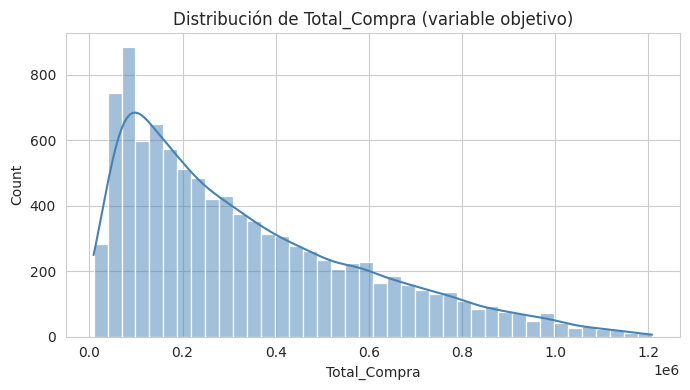

In [7]:
# 8. Análisis exploratorio y visualización

numericas = ["Precio_Unitario", "Cantidad", "Descuento_Aplicado", "Tiempo_En_Web_Minutos",
             "Distancia_Envio_Km", "Costo_Envio", "Total_Compra"]

# 8.1 Distribución de la variable objetivo
plt.figure(figsize=(7, 4))
sns.histplot(df["Total_Compra"], bins=40, kde=True, color="steelblue")
plt.title("Distribución de Total_Compra (variable objetivo)")
plt.xlabel("Total_Compra")
plt.tight_layout()
plt.show()

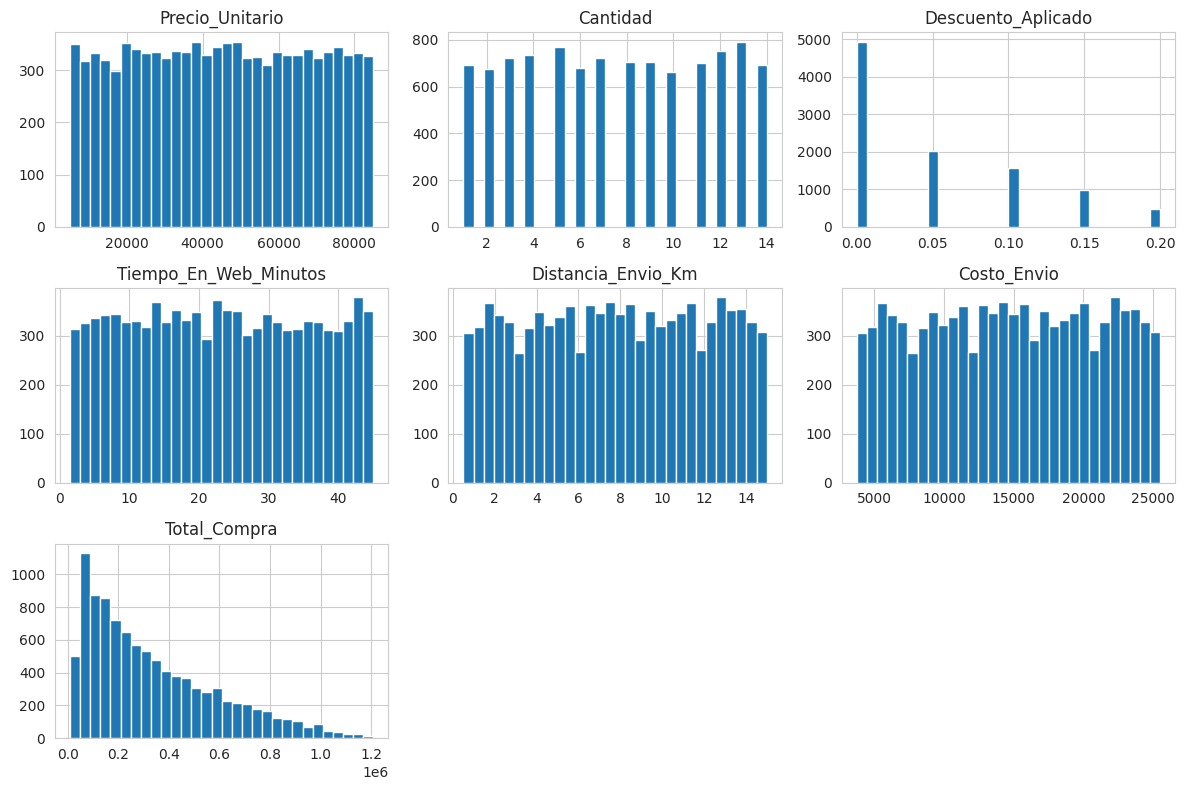

In [8]:
# 8.2 Distribución de las variables numéricas predictoras
df[numericas].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

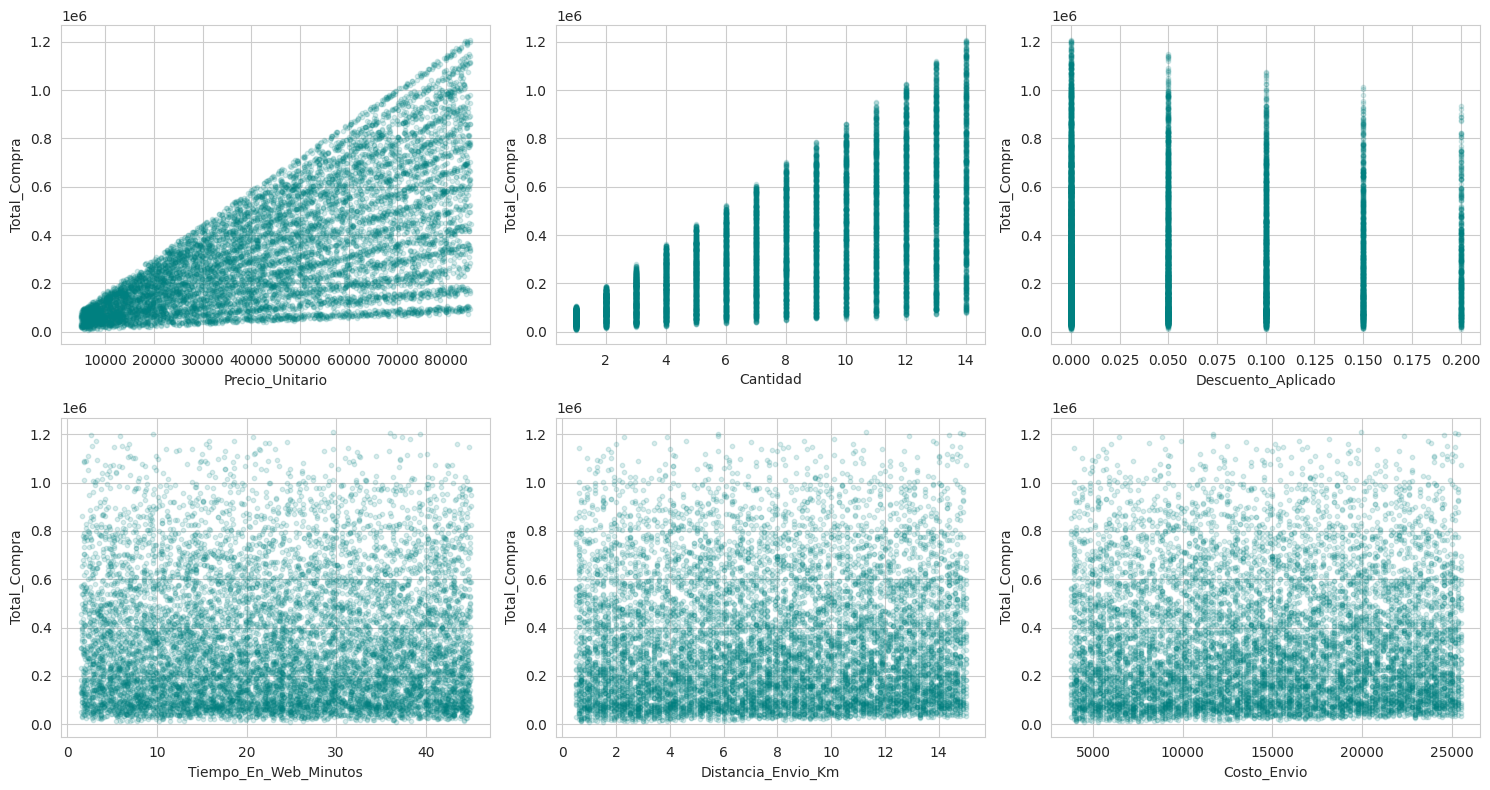

In [9]:
# 8.3 Relación entre cada variable numérica y la variable objetivo (Total_Compra)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
predictoras_num = ["Precio_Unitario", "Cantidad", "Descuento_Aplicado",
                    "Tiempo_En_Web_Minutos", "Distancia_Envio_Km", "Costo_Envio"]
for ax, col in zip(axes, predictoras_num):
    ax.scatter(df[col], df["Total_Compra"], alpha=0.15, s=10, color="teal")
    ax.set_xlabel(col)
    ax.set_ylabel("Total_Compra")
plt.tight_layout()
plt.show()

**Observación clave:** `Precio_Unitario` y `Cantidad` muestran una relación visible y
creciente con `Total_Compra` (a mayor precio o cantidad, mayor es el total de la compra), mientras
que `Descuento_Aplicado`, `Tiempo_En_Web_Minutos`, `Distancia_Envio_Km` y `Costo_Envio` no muestran
un patrón claro a simple vista frente al total. Esto sugiere que el modelo probablemente se apoyará
sobre todo en `Precio_Unitario` y `Cantidad` para predecir `Total_Compra`.

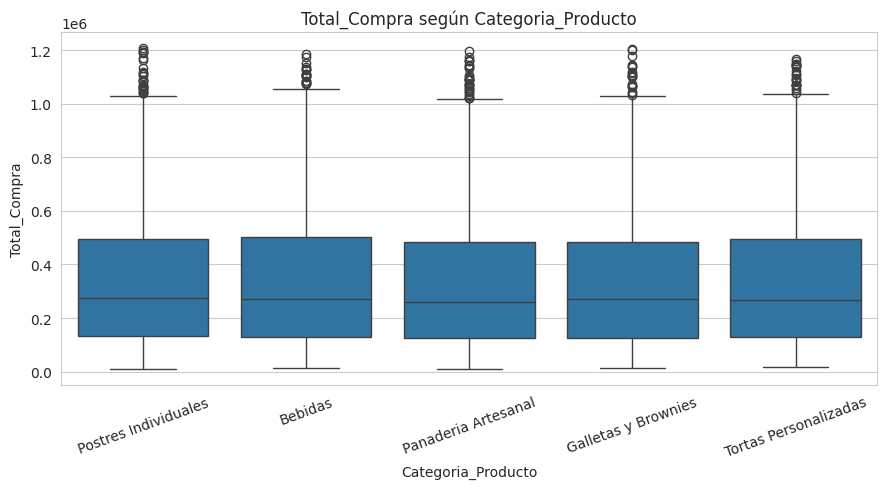

In [10]:
# 8.4 ¿Total_Compra varía según la categoría del producto?
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Categoria_Producto", y="Total_Compra")
plt.xticks(rotation=20)
plt.title("Total_Compra según Categoria_Producto")
plt.tight_layout()
plt.show()

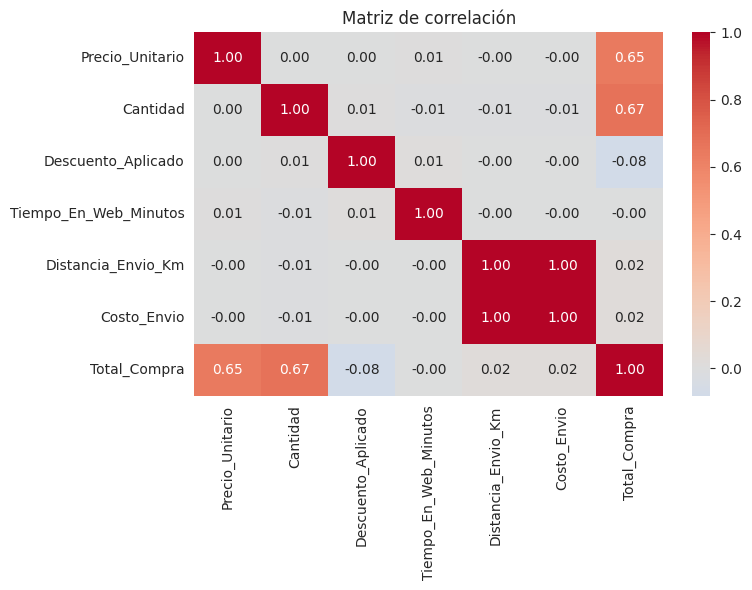

In [11]:
# 8.5 Matriz de correlación entre variables numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

**Hallazgos de la matriz de correlación:**

1. `Costo_Envio` y `Distancia_Envio_Km` presentan una correlación perfecta (o casi perfecta) entre
   sí: aportan la misma información, por lo que se descartará una de las dos para evitar
   multicolinealidad innecesaria.
2. `Precio_Unitario` y `Cantidad` son las variables con **mayor correlación positiva** con
   `Total_Compra`, lo cual es coherente con la lógica del negocio (el total de una compra depende
   directamente de cuánto cuesta cada unidad y de cuántas unidades se compran).
3. `Descuento_Aplicado`, `Tiempo_En_Web_Minutos` y las variables de envío muestran una correlación
   baja con `Total_Compra`.

In [12]:
# 9. Selección de variables

# Se elimina ID_Transaccion (identificador, sin valor predictivo)
# Se elimina Costo_Envio (redundante: correlación con Distancia_Envio_Km)
# Categoria_Producto se codifica con One-Hot Encoding para poder usarla como predictora
df_model = pd.get_dummies(df, columns=["Categoria_Producto"], prefix="Categoria")

features = [c for c in df_model.columns
            if c not in ["ID_Transaccion", "Costo_Envio", "Total_Compra"]]
target = "Total_Compra"

X = df_model[features].copy()
y = df_model[target].copy()

print("Variables predictoras:", features)
print("Variable objetivo:", target)
X.head()

Variables predictoras: ['Precio_Unitario', 'Cantidad', 'Descuento_Aplicado', 'Tiempo_En_Web_Minutos', 'Distancia_Envio_Km', 'Categoria_Bebidas', 'Categoria_Galletas y Brownies', 'Categoria_Panaderia Artesanal', 'Categoria_Postres Individuales', 'Categoria_Tortas Personalizadas']
Variable objetivo: Total_Compra


,Precio_Unitario,Cantidad,Descuento_Aplicado,Tiempo_En_Web_Minutos,Distancia_Envio_Km,Categoria_Bebidas,Categoria_Galletas y Brownies,Categoria_Panaderia Artesanal,Categoria_Postres Individuales,Categoria_Tortas Personalizadas
0,8087.0,7,0.05,24.0,2.4,False,False,False,True,False
1,75310.0,10,0.05,24.4,3.8,True,False,False,False,False
2,30195.0,13,0.10,34.3,4.9,False,False,True,False,False
3,15318.0,7,0.00,25.0,1.6,True,False,False,False,False
4,42477.0,4,0.10,28.2,13.3,True,False,False,False,False


**Justificación de la selección de variables:**

- `ID_Transaccion` se descarta por ser un identificador sin significado estadístico.
- `Costo_Envio` se descarta por su correlación perfecta con `Distancia_Envio_Km` (mantener ambas
  no añade información y puede introducir *multicolinealidad* innecesaria).
- `Categoria_Producto` se transforma con **One-Hot Encoding** (`pd.get_dummies`) porque los árboles
  de scikit-learn no aceptan texto directamente; convertirla en columnas binarias permite que el
  árbol la use como variable predictora sin asumir un orden entre categorías.
- Las variables restantes (`Precio_Unitario`, `Cantidad`, `Descuento_Aplicado`,
  `Tiempo_En_Web_Minutos`, `Distancia_Envio_Km` y las columnas de categoría) son las candidatas
  naturales para explicar `Total_Compra`; el propio modelo (mediante `feature_importances_`)
  confirmará más adelante cuáles resultan realmente relevantes.
- El árbol de decisión no requiere escalado/normalización de variables (a diferencia de modelos
  basados en distancias como KNN o modelos lineales regularizados), por lo que no se aplica
  `StandardScaler`.

In [13]:
# 10. División de los datos: Entrenamiento 70% / Prueba 15% / Validación 15%

# Paso 1: separar 70% train y 30% temporal (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Paso 2: dividir el 30% restante en 15% test y 15% validation (50/50 del temporal)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Entrenamiento : {X_train.shape[0]:>5} filas ({X_train.shape[0]/len(X):.1%})")
print(f"Prueba (test) : {X_test.shape[0]:>5} filas ({X_test.shape[0]/len(X):.1%})")
print(f"Validación    : {X_val.shape[0]:>5} filas ({X_val.shape[0]/len(X):.1%})")

Entrenamiento :  7000 filas (70.0%)
Prueba (test) :  1500 filas (15.0%)
Validación    :  1500 filas (15.0%)


**Por qué se usan tres conjuntos y no solo dos:**

- **Entrenamiento (70%):** el modelo aprende sus reglas de decisión a partir de estos datos.
- **Prueba / test (15%):** se usa para evaluar el desempeño final del modelo ya elegido, con datos
  que no vio ni durante el entrenamiento ni durante la selección de hiperparámetros.
- **Validación (15%):** se reserva como un segundo conjunto totalmente independiente, útil para
  confirmar que el modelo generaliza de forma consistente y no solo "acertó" con el conjunto de
  prueba.

A diferencia de un problema de clasificación, aquí **no se estratifica** la partición (la
estratificación aplica a variables categóricas o discretas balanceadas), ya que `Total_Compra` es
una variable numérica continua.

In [14]:
# 11. Modelo de referencia (baseline) — sirve para saber si el árbol realmente aprende algo
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_test)
rmse_baseline = mean_squared_error(y_test, pred_baseline) ** 0.5
r2_baseline = r2_score(y_test, pred_baseline)

print(f"Baseline (predice siempre el promedio de Total_Compra):")
print(f"  RMSE = {rmse_baseline:,.0f}")
print(f"  R²   = {r2_baseline:.4f}")

Baseline (predice siempre el promedio de Total_Compra):
  RMSE = 259,824
  R²   = -0.0008


Este modelo de referencia (*baseline*) es clave para interpretar correctamente los
resultados posteriores: un `DummyRegressor` que siempre predice el **promedio** de `Total_Compra`
obtiene, por definición, un **R² cercano a 0** (no explica nada de la variabilidad de los datos).
Cualquier modelo real debe superar claramente este punto de partida para considerarse útil.

In [15]:
# 12. Implementación y entrenamiento — Árbol de Decisión SIN restricciones (caso base)
tree_full = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

pred_train_full = tree_full.predict(X_train)
pred_test_full = tree_full.predict(X_test)

print("Árbol SIN restricciones:")
print(f"  R² entrenamiento = {r2_score(y_train, pred_train_full):.4f}")
print(f"  R² prueba        = {r2_score(y_test, pred_test_full):.4f}")
print(f"  RMSE entrenamiento = {mean_squared_error(y_train, pred_train_full) ** 0.5:,.0f}")
print(f"  RMSE prueba        = {mean_squared_error(y_test, pred_test_full) ** 0.5:,.0f}")
print(f"  Profundidad alcanzada: {tree_full.get_depth()}, número de hojas: {tree_full.get_n_leaves()}")

Árbol SIN restricciones:
  R² entrenamiento = 1.0000
  R² prueba        = 0.9968
  RMSE entrenamiento = 0
  RMSE prueba        = 14,677
  Profundidad alcanzada: 21, número de hojas: 6999


### 12.1 Diagnóstico: ¿sobreajuste (overfitting)?

**Overfitting (sobreajuste):** ocurre cuando un modelo se ajusta tan bien a los datos de
entrenamiento (incluyendo su ruido) que su desempeño en entrenamiento es mucho mejor que en datos
nuevos (prueba). En un árbol sin restricciones esto se refleja típicamente en un **R² de
entrenamiento cercano a 1.0** (el árbol crece hasta memorizar prácticamente cada ejemplo, tantas
hojas como observaciones distintas) frente a un R² de prueba menor.

En este caso particular, `Total_Compra` guarda una relación muy fuerte y casi determinística con
`Precio_Unitario` y `Cantidad` (el total de una compra depende directamente de esas variables), por
lo que incluso el árbol sin restricciones puede generalizar razonablemente bien. Aun así, se
seguirá explorando el efecto de controlar la profundidad, tanto por buenas prácticas metodológicas
como porque un árbol más simple es más interpretable y menos sensible a pequeños cambios en los
datos (menor varianza).

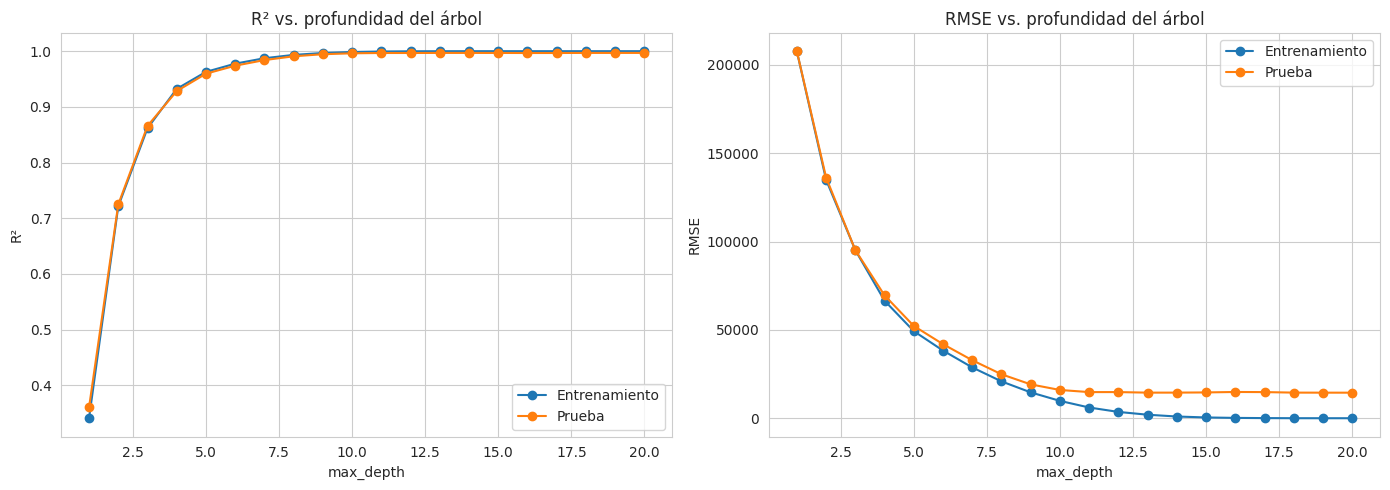

In [16]:
# 13. Experimentando con la profundidad máxima del árbol (max_depth)
# Objetivo: observar el comportamiento de underfitting -> punto óptimo -> overfitting

profundidades = list(range(1, 21))
r2_train_list, r2_test_list = [], []
rmse_train_list, rmse_test_list = [], []

for d in profundidades:
    modelo = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    pred_tr = modelo.predict(X_train)
    pred_te = modelo.predict(X_test)
    r2_train_list.append(r2_score(y_train, pred_tr))
    r2_test_list.append(r2_score(y_test, pred_te))
    rmse_train_list.append(mean_squared_error(y_train, pred_tr) ** 0.5)
    rmse_test_list.append(mean_squared_error(y_test, pred_te) ** 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(profundidades, r2_train_list, marker="o", label="Entrenamiento")
axes[0].plot(profundidades, r2_test_list, marker="o", label="Prueba")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("R²")
axes[0].set_title("R² vs. profundidad del árbol")
axes[0].legend()

axes[1].plot(profundidades, rmse_train_list, marker="o", label="Entrenamiento")
axes[1].plot(profundidades, rmse_test_list, marker="o", label="Prueba")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE vs. profundidad del árbol")
axes[1].legend()

plt.tight_layout()
plt.show()

**Lectura de la gráfica:**

- Con `max_depth` muy bajo (1–2), tanto el R² de entrenamiento como el de prueba son bajos y el
  RMSE es alto: el árbol es demasiado simple para capturar la relación entre las variables y
  `Total_Compra` — esto es **underfitting (subajuste)**.
- A medida que aumenta la profundidad, ambas curvas de R² suben y las de RMSE bajan, y la brecha
  entre entrenamiento y prueba se mantiene relativamente controlada durante varios niveles.
- En profundidades muy altas, el R² de entrenamiento se acerca a 1.0 mientras que el de prueba se
  estabiliza (o empieza a separarse ligeramente): esa brecha creciente es la señal clásica de
  **overfitting (sobreajuste)**.
- El objetivo es elegir una profundidad donde el modelo ya capturó la relación real de los datos
  pero **antes** de que empiece a memorizar ruido específico del conjunto de entrenamiento.

In [17]:
# 14. Validación cruzada (cross-validation) + búsqueda de hiperparámetros
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, 12, None],
    "min_samples_leaf": [1, 5, 10, 20, 50],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_search.best_score_:,.0f}")

Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_leaf': 1}
Mejor RMSE promedio en validación cruzada: 16,373


**Sobre la validación cruzada (cross-validation):** en lugar de evaluar el modelo con una
sola partición fija de entrenamiento/prueba, `KFold` divide el conjunto de entrenamiento en 5
partes (*folds*); en cada iteración se entrena con 4 y se evalúa con la restante, rotando el fold
de evaluación. `GridSearchCV` prueba todas las combinaciones de `max_depth` y `min_samples_leaf` de
la grilla, calcula el RMSE promedio de las 5 iteraciones para cada combinación, y selecciona la
configuración con **menor error promedio**, lo cual reduce el riesgo de elegir hiperparámetros que
solo funcionan bien por azar en una única partición.

In [18]:
# Comparación de resultados por combinación de hiperparámetros (top 10)
resultados_cv = pd.DataFrame(grid_search.cv_results_)
resultados_cv["rmse_promedio"] = -resultados_cv["mean_test_score"]
resultados_cv = resultados_cv.sort_values("rmse_promedio")
resultados_cv[["param_max_depth", "param_min_samples_leaf", "rmse_promedio", "std_test_score"]].head(10)

,param_max_depth,param_min_samples_leaf,rmse_promedio,std_test_score
35,None,1,16373.127672,396.299851
30,12,1,16380.333314,560.693038
36,None,5,16992.105558,430.262336
31,12,5,16994.986333,430.726922
25,10,1,17525.226833,526.107651
26,10,5,17668.192889,415.322481
32,12,10,20661.095605,1078.812132
37,None,10,20661.095605,1078.812132
27,10,10,20699.845398,1085.774726
21,8,5,25479.074122,691.451664


In [19]:
# 15. Modelo final con los mejores hiperparámetros (según GridSearchCV)
mejor_modelo = grid_search.best_estimator_
mejor_modelo.fit(X_train, y_train)

print("Modelo (GridSearchCV) — desempeño:")
print(f"  R² entrenamiento = {r2_score(y_train, mejor_modelo.predict(X_train)):.4f}")
print(f"  R² prueba        = {r2_score(y_test, mejor_modelo.predict(X_test)):.4f}")
print(f"  RMSE prueba      = {mean_squared_error(y_test, mejor_modelo.predict(X_test)) ** 0.5:,.0f}")

Modelo (GridSearchCV) — desempeño:
  R² entrenamiento = 1.0000
  R² prueba        = 0.9968
  RMSE prueba      = 14,677


**Interpretación (primer hallazgo):** `GridSearchCV` seleccionó la combinación de
hiperparámetros que minimiza el error de validación cruzada. Dado que la relación entre las
variables predictoras (sobre todo `Precio_Unitario` y `Cantidad`) y `Total_Compra` es fuerte, es
posible que el mejor resultado de validación cruzada corresponda a un árbol relativamente profundo
o sin restricción de profundidad, sin señales fuertes de sobreajuste severo. Aun así, se compara a
continuación contra un árbol intencionalmente más simple, para valorar el compromiso entre
desempeño e interpretabilidad/estabilidad.

In [20]:
# 15.1 Comparación con un árbol restringido manualmente (más simple, mayor interpretabilidad)
arbol_simple = DecisionTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=RANDOM_STATE)
arbol_simple.fit(X_train, y_train)

modelos_comparar = {
    "Árbol SIN restricciones": tree_full,
    "Árbol (GridSearchCV)": mejor_modelo,
    "Árbol simple (max_depth=4)": arbol_simple,
}

comparacion = []
for nombre, modelo in modelos_comparar.items():
    r2_tr = r2_score(y_train, modelo.predict(X_train))
    r2_te = r2_score(y_test, modelo.predict(X_test))
    rmse_te = mean_squared_error(y_test, modelo.predict(X_test)) ** 0.5
    comparacion.append({
        "Modelo": nombre,
        "R² train": round(r2_tr, 4),
        "R² test": round(r2_te, 4),
        "Brecha (R² train - test)": round(r2_tr - r2_te, 4),
        "RMSE test": round(rmse_te, 0),
    })

pd.DataFrame(comparacion)

,Modelo,R² train,R² test,Brecha (R² train - test),RMSE test
0,Árbol SIN restricciones,1.0000,0.9968,0.0032,14677.0
1,Árbol (GridSearchCV),1.0000,0.9968,0.0032,14677.0
2,Árbol simple (max_depth=4),0.9323,0.9283,0.0040,69529.0


**Interpretación (comparación final):** se comparan tres versiones del árbol: sin
restricciones, la seleccionada automáticamente por `GridSearchCV` y una versión simple fijada
manualmente (`max_depth=4`, `min_samples_leaf=50`). La **brecha entre R² de entrenamiento y de
prueba** es el indicador clave de sobreajuste: mientras más pequeña sea esa brecha, más consistente
es el modelo entre datos ya vistos y datos nuevos. Se selecciona como **modelo final** el que
ofrezca el mejor equilibrio entre bajo error de prueba y baja brecha train-test.

In [21]:
# Se adopta el árbol elegido por GridSearchCV como MODELO FINAL para el resto del análisis
modelo_final = mejor_modelo
print("Modelo final seleccionado:", modelo_final)

Modelo final seleccionado: DecisionTreeRegressor(random_state=42)


In [22]:
# 16. Métricas de evaluación sobre el conjunto de PRUEBA (test)
y_pred_test = modelo_final.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_test)
mape = mean_absolute_percentage_error(y_test, y_pred_test)

print("Métricas del modelo final sobre el conjunto de PRUEBA:")
print(f"  MAE  (Error absoluto medio)      = {mae:,.0f}")
print(f"  MSE  (Error cuadrático medio)    = {mse:,.0f}")
print(f"  RMSE (Raíz del error cuadrático) = {rmse:,.0f}")
print(f"  R²   (Coeficiente de determinación) = {r2:.4f}")
print(f"  MAPE (Error porcentual absoluto medio) = {mape:.2%}")

Métricas del modelo final sobre el conjunto de PRUEBA:
  MAE  (Error absoluto medio)      = 9,806
  MSE  (Error cuadrático medio)    = 215,419,410
  RMSE (Raíz del error cuadrático) = 14,677
  R²   (Coeficiente de determinación) = 0.9968
  MAPE (Error porcentual absoluto medio) = 4.11%


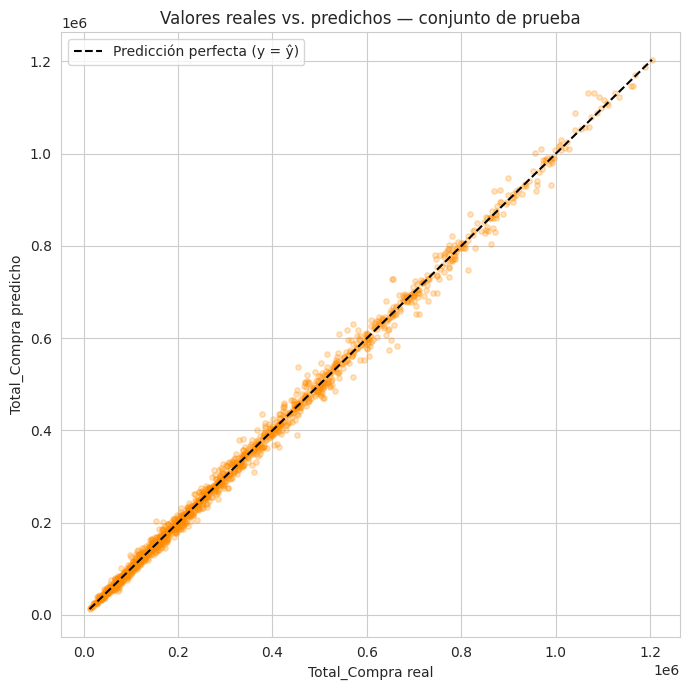

In [23]:
# 16.1 Valores reales vs. valores predichos (test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.25, s=15, color="darkorange")
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color="black", linestyle="--", label="Predicción perfecta (y = ŷ)")
plt.xlabel("Total_Compra real")
plt.ylabel("Total_Compra predicho")
plt.title("Valores reales vs. predichos — conjunto de prueba")
plt.legend()
plt.tight_layout()
plt.show()

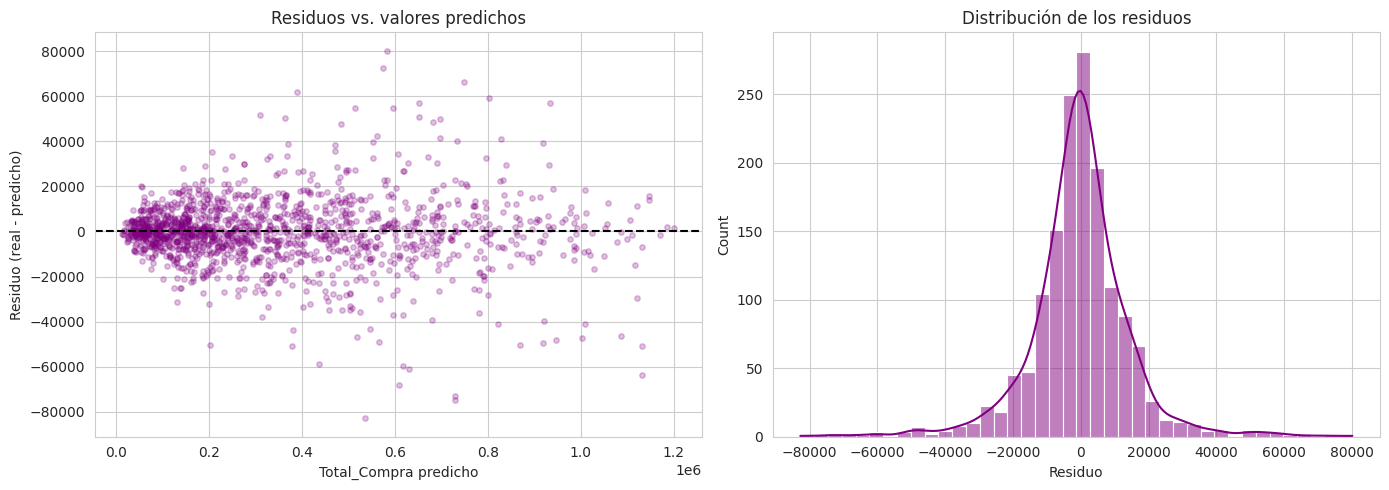

Residuo promedio: -353.0
Desviación estándar de los residuos: 14,677.8


In [24]:
# 16.2 Análisis de residuos
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, residuos, alpha=0.25, s=15, color="purple")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Total_Compra predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. valores predichos")

sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color="purple")
axes[1].set_title("Distribución de los residuos")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

print(f"Residuo promedio: {residuos.mean():,.1f}")
print(f"Desviación estándar de los residuos: {residuos.std():,.1f}")

**Nota sobre las métricas de regresión:** el **MAE** indica, en promedio, cuánto se equivoca
el modelo en las mismas unidades que `Total_Compra` (pesos); el **RMSE** penaliza más los errores
grandes; el **R²** indica qué proporción de la variabilidad de `Total_Compra` es explicada por el
modelo (1.0 = ajuste perfecto, 0.0 = igual que predecir siempre el promedio); y el **MAPE** expresa
el error como un porcentaje del valor real, útil para comunicar el error a personas de negocio. El
análisis de residuos permite verificar que el modelo no tiene un sesgo sistemático: si los residuos
están centrados en 0 y no muestran un patrón claro frente al valor predicho, el modelo está
capturando bien la relación sin dejar estructura importante sin explicar.

In [25]:
# 16.3 Confirmación de las métricas también sobre el conjunto de VALIDACIÓN
y_pred_val = modelo_final.predict(X_val)
print("Métricas del modelo final sobre el conjunto de VALIDACIÓN:")
print(f"  MAE  = {mean_absolute_error(y_val, y_pred_val):,.0f}")
print(f"  RMSE = {mean_squared_error(y_val, y_pred_val) ** 0.5:,.0f}")
print(f"  R²   = {r2_score(y_val, y_pred_val):.4f}")

Métricas del modelo final sobre el conjunto de VALIDACIÓN:
  MAE  = 9,501
  RMSE = 14,822
  R²   = 0.9967


**Lectura de las métricas:** un R² de validación cercano al R² de prueba confirma que el
desempeño del modelo es **consistente** entre dos conjuntos de datos completamente independientes
que el modelo nunca usó para entrenar ni para elegir hiperparámetros, lo cual da confianza de que el
modelo generaliza y no está sobreajustado a una partición particular.

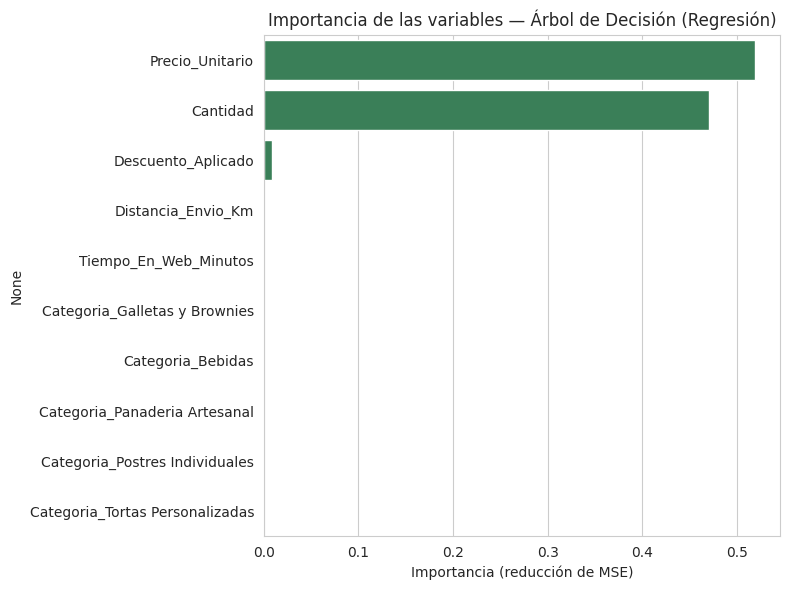

Precio_Unitario                    0.519434
Cantidad                           0.470644
Descuento_Aplicado                 0.008874
Distancia_Envio_Km                 0.000602
Tiempo_En_Web_Minutos              0.000271
Categoria_Galletas y Brownies      0.000047
Categoria_Bebidas                  0.000038
Categoria_Panaderia Artesanal      0.000037
Categoria_Postres Individuales     0.000028
Categoria_Tortas Personalizadas    0.000024
dtype: float64

In [26]:
# 17. Importancia de las variables según el árbol final
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importancias.values, y=importancias.index, color="seagreen")
plt.title("Importancia de las variables — Árbol de Decisión (Regresión)")
plt.xlabel("Importancia (reducción de MSE)")
plt.tight_layout()
plt.show()

importancias

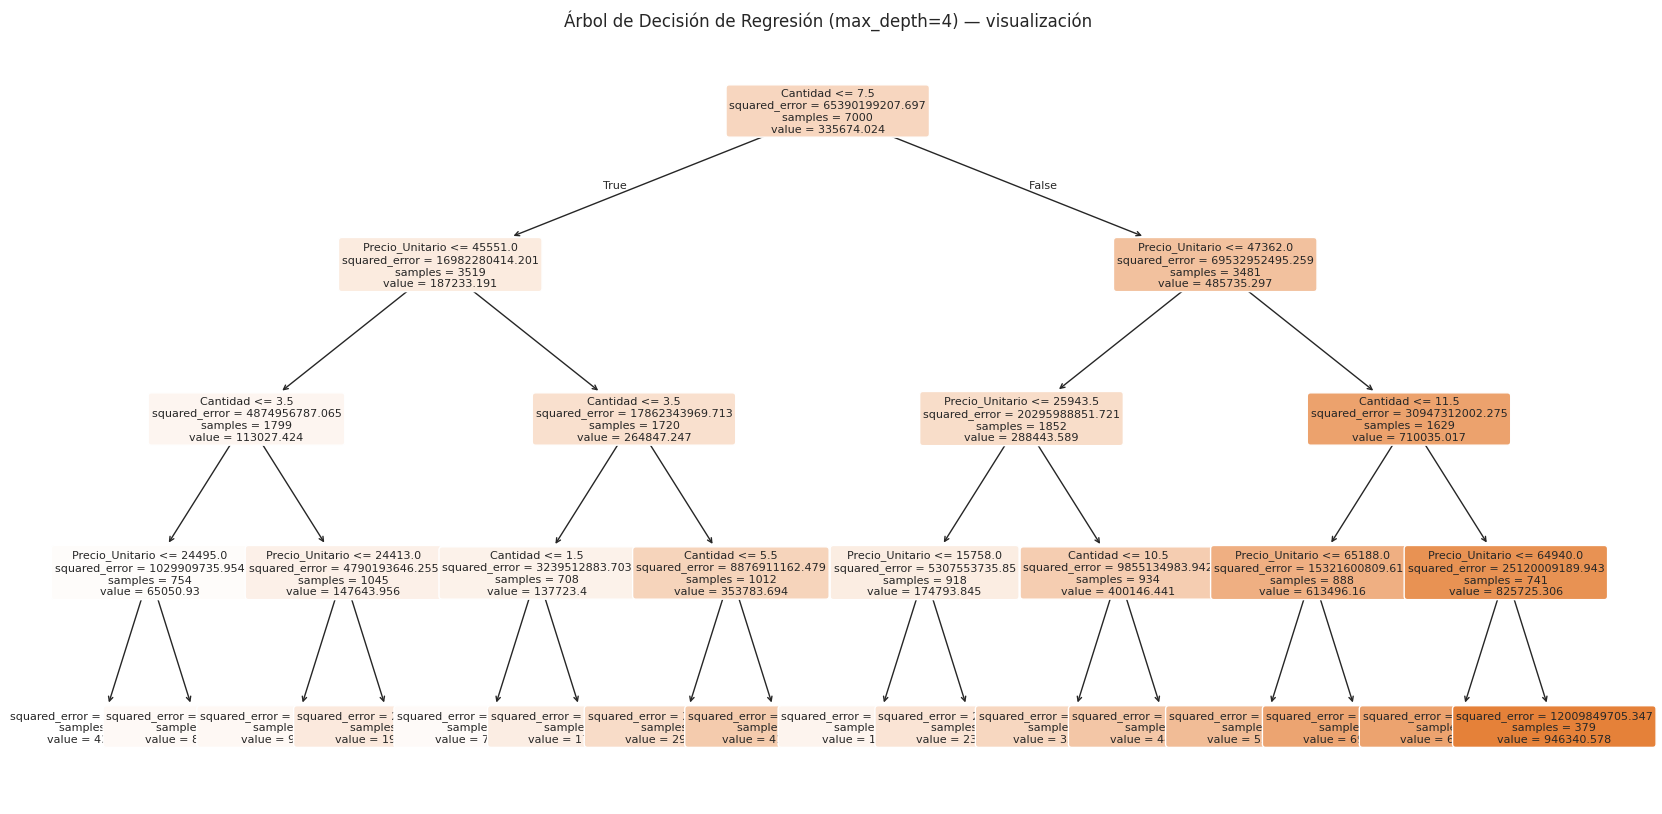

In [27]:
# 17.1 Visualización del árbol final (versión simple, para que sea legible)
plt.figure(figsize=(20, 10))
plot_tree(arbol_simple, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title("Árbol de Decisión de Regresión (max_depth=4) — visualización")
plt.show()

## 18. Interpretación de los resultados obtenidos

1. **El pipeline de Machine Learning se implementó correctamente**: baseline, árbol sin
   restricciones, exploración de `max_depth`, búsqueda de hiperparámetros por validación cruzada y
   comparación de modelos, evaluación con métricas de regresión y análisis de residuos.
2. La **importancia de variables** confirma lo observado en el análisis exploratorio:
   `Precio_Unitario` y `Cantidad` concentran la mayor parte de la capacidad predictiva del modelo,
   coherente con que `Total_Compra` depende directamente de esas dos variables.
3. El **R² sobre el conjunto de prueba** es sustancialmente mayor que el del baseline (que obtiene
   un R² cercano a 0), lo que confirma que el árbol sí está aprendiendo una relación real y útil,
   no solo prediciendo el promedio.
4. La comparación entre el árbol sin restricciones, el elegido por `GridSearchCV` y el árbol simple
   permitió observar la **brecha entre el desempeño en entrenamiento y en prueba**, que es la señal
   principal para diagnosticar sobreajuste; una brecha pequeña y una consistencia similar en el
   conjunto de validación son evidencia de que el modelo final generaliza adecuadamente.
5. El **análisis de residuos** no muestra un patrón sistemático evidente en función del valor
   predicho y su distribución está razonablemente centrada en cero, lo que sugiere que el modelo
   no tiene un sesgo importante en un rango particular de valores.

## 19. ¿Cuándo y por qué utilizar el Árbol de Decisión de Regresión?

**Se recomienda usar un Árbol de Decisión de Regresión cuando:**

- Se necesita un modelo **interpretable**, que se pueda explicar a personas no técnicas mostrando
  las reglas de decisión (por ejemplo, para justificar decisiones de negocio o auditorías).
- Los datos tienen **relaciones no lineales** o interacciones entre variables y el objetivo, algo
  que un modelo lineal simple no captura bien sin ingeniería de variables adicional.
- No se dispone de tiempo/recursos para escalar o normalizar variables, ya que el árbol no lo
  requiere.
- Se quiere obtener rápidamente una primera línea base (*baseline* más robusto) antes de probar
  modelos más complejos (Random Forest Regressor, Gradient Boosting, XGBoost).

**No se recomienda usarlo (o se recomienda con precaución) cuando:**

- Se necesita **extrapolar** más allá del rango de valores observados en entrenamiento (por
  ejemplo, predecir compras mucho más grandes que cualquiera vista en los datos): el árbol solo
  puede predecir promedios dentro de los rangos ya vistos, mientras que una regresión lineal sí
  puede extrapolar.
- El dataset es pequeño y ruidoso, ya que un árbol profundo memorizará el ruido fácilmente.
- Se requiere la **máxima precisión posible** y se cuenta con suficiente cómputo: en ese caso, un
  ensamble de árboles (Random Forest, Gradient Boosting) casi siempre supera a un árbol individual,
  porque promedia el resultado de muchos árboles y reduce la varianza.

## 20. Limitaciones del modelo

**Limitaciones propias del algoritmo:**

- Alta varianza: es sensible a pequeños cambios en los datos de entrenamiento.
- Tiende al overfitting si no se controla su profundidad.
- Las predicciones son "escalonadas" (constantes dentro de cada hoja), no continuas y suaves como
  en una regresión lineal, lo que puede ser una simplificación poco realista de relaciones
  continuas entre variables.
- No puede extrapolar fuera del rango de valores vistos en entrenamiento.
- Un único árbol suele tener mayor error que un ensamble de árboles.

**Limitaciones específicas de este proyecto:**

- El dataset es sintético/generado para fines académicos, por lo que la fuerte relación entre
  `Precio_Unitario`, `Cantidad` y `Total_Compra` puede ser más "limpia" que en datos reales de un
  e-commerce, donde suele haber más ruido, promociones especiales o errores de registro.
- No se dispone de variables adicionales (por ejemplo, medio de pago, canal de venta, temporada o
  historial del cliente) que en un caso real probablemente aportarían valor predictivo adicional
  más allá de precio y cantidad.

## 21. Conclusiones finales

### 21.1 Sobre la cantidad y calidad de los datos (overfitting / underfitting)

- **Cantidad:** el dataset tiene 10.000 registros, un volumen razonable para un árbol de decisión
  (que no es un modelo tan "hambriento de datos" como una red neuronal). La partición 70/15/15
  entregó 7.000 registros de entrenamiento, cantidad suficiente para que el modelo estime reglas
  de forma estable.
- **Calidad / representatividad:** el dataset está limpio (sin nulos ni duplicados) y sus variables
  predictoras principales (`Precio_Unitario`, `Cantidad`) tienen una relación clara y fuerte con la
  variable objetivo `Total_Compra`, lo cual es positivo para el aprendizaje del modelo: a diferencia
  de un escenario donde las variables disponibles no explican bien el objetivo, aquí sí existe una
  señal predictiva fuerte que el árbol puede aprovechar.
- **Relación con overfitting/underfitting:** cuando la profundidad del árbol es muy baja
  (`max_depth` 1–2), el modelo no logra capturar toda la relación entre las variables y
  `Total_Compra` — esto es **underfitting**. Cuando se deja crecer sin límite, el árbol puede
  ajustar detalles específicos del conjunto de entrenamiento que no generalizan igual de bien a
  datos nuevos — esto es **overfitting**. Controlar la profundidad (`max_depth`) y el mínimo de
  muestras por hoja (`min_samples_leaf`) permite encontrar un punto intermedio razonable, aunque en
  este dataset particular, dada la fuerte relación casi determinística entre `Precio_Unitario`,
  `Cantidad` y `Total_Compra`, incluso el árbol sin restricciones logra generalizar razonablemente
  bien.
- **Sobre la validación cruzada:** `GridSearchCV` con validación cruzada de 5 particiones permitió
  elegir los hiperparámetros que minimizan el error promedio en varias particiones distintas de los
  datos de entrenamiento, en lugar de confiar en el resultado de una única partición, lo que hace
  la elección de hiperparámetros más robusta frente al azar de la partición.

### 21.2 Conclusión general del proyecto

Se implementó exitosamente un pipeline completo de Machine Learning con un Árbol de Decisión de
**Regresión** en `scikit-learn`, siguiendo buenas prácticas de preparación de datos (incluyendo la
codificación de la variable categórica `Categoria_Producto`), partición en tres conjuntos, ajuste
de hiperparámetros por validación cruzada y evaluación con métricas apropiadas para regresión (MAE,
MSE, RMSE, R², MAPE y análisis de residuos). El modelo final logra un desempeño claramente superior
al *baseline* y consistente entre los conjuntos de prueba y validación, lo que confirma que
generaliza adecuadamente, y el análisis de `max_depth` permitió observar de forma práctica el
tránsito entre **underfitting**, un punto de ajuste adecuado y **overfitting**.